# Data Engineering & Feature Representation

### Course: Lab of Information Systems and Analytics
### University: Ca' Foscari University of Venice

This notebook is a comprehensive didactic resource designed to bridge the gap between theoretical concepts and practical implementation. We will explore advanced Feature Engineering, Feature Selection, and the evolution of Text Representation from statistical methods to state-of-the-art Transformers.

# 1. Introduction to Scikit-Learn

Scikit-Learn (sklearn) is the most widely used Python library for classical Machine Learning. It provides a consistent API for a wide range of algorithms and preprocessing techniques.

### Library Structure
Scikit-Learn is organized into modules based on the task:
- `sklearn.preprocessing`: Scaling, encoding, and normalization.
- `sklearn.feature_selection`: Algorithms to select the most relevant features.
- `sklearn.decomposition`: Dimensionality reduction (e.g., PCA).
- `sklearn.model_selection`: Tools for cross-validation and hyperparameter tuning.
- `sklearn.linear_model`, `sklearn.ensemble`, etc.: Implementation of ML algorithms.

### The Estimator API
Almost all objects in sklearn share a common interface:
1. **`fit(X, y)`**: Learns the parameters from the data (e.g., mean and std for scaling).
2. **`transform(X)`**: Applies the learned parameters to transform the data.
3. **`fit_transform(X, y)`**: Does both in one step (more efficient).
4. **`predict(X)`**: For models, predicts the target for new data.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Setting visual style for the projector
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 2. Categorical Feature Encoding

### 2.1 Theoretical Foundation
Machine Learning algorithms are mathematical models that operate on numerical data. Categorical features (text-based labels) must be converted into numbers. We distinguish between:
*   **Nominal Data**: Categories with no inherent order (e.g., Gender, Color, PreferredLoginDevice).
*   **Ordinal Data**: Categories with a meaningful order (e.g., Satisfaction Score: Low, Medium, High).

### 2.2 Techniques
1.  **One-Hot Encoding (OHE)**: Creates a binary column for each category. Ideal for nominal data. It avoids implying an artificial order.
2.  **Ordinal Encoding**: Assigns a unique integer to each category based on its rank. Ideal for ordinal data.

**Note**: To avoid multicollinearity in OHE we can drop one of the columns (usually the first).

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Sample Data for Encoding
data = {
    'Device': ['Mobile', 'Desktop', 'Mobile', 'Tablet', 'Desktop'],
    'Satisfaction': ['Low', 'High', 'Medium', 'Low', 'High']
}
df_cat = pd.DataFrame(data)
print("--- Original Data ---")
display(df_cat)

# 2.2.1 One-Hot Encoding with Scikit-Learn (Nominal)
# sparse_output=False returns a dense array instead of a sparse matrix
ohe = OneHotEncoder(sparse_output=False, drop='first')
X_device_ohe = ohe.fit_transform(df_cat[['Device']])
df_ohe = pd.DataFrame(X_device_ohe, columns=ohe.get_feature_names_out(['Device']))

print("\n--- After One-Hot Encoding (Device) ---")
display(df_ohe)

--- Original Data ---


,Device,Satisfaction
0,Mobile,Low
1,Desktop,High
2,Mobile,Medium
3,Tablet,Low
4,Desktop,High



--- After One-Hot Encoding (Device) ---


,Device_Mobile,Device_Tablet
0,1.0,0.0
1,0.0,0.0
2,1.0,0.0
3,0.0,1.0
4,0.0,0.0


In [ ]:
X_device_ohe

array([[1., 0.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 0.]])

In [ ]:
# 2.2.2 Ordinal Encoding with Scikit-Learn (Ordinal)
# We must specify the order explicitly for OrdinalEncoder
categories_order = [['Low', 'Medium', 'High']]
oe = OrdinalEncoder(categories=categories_order)
X_sat_ord = oe.fit_transform(df_cat[['Satisfaction']])
df_cat['Satisfaction_Encoded'] = X_sat_ord

print("\n--- After Ordinal Encoding (Satisfaction) ---")
display(df_cat[['Satisfaction', 'Satisfaction_Encoded']])


--- After Ordinal Encoding (Satisfaction) ---


,Satisfaction,Satisfaction_Encoded
0,Low,0.0
1,High,2.0
2,Medium,1.0
3,Low,0.0
4,High,2.0


In [ ]:
# Create the new vectorial representation for the data
print("\n--- Final Vectorial Representation (X) ---")
X = np.concatenate([X_device_ohe, X_sat_ord], axis=1)
display(pd.DataFrame(X, columns=list(df_ohe.columns) + ['Satisfaction_Encoded']))


--- Final Vectorial Representation (X) ---


,Device_Mobile,Device_Tablet,Satisfaction_Encoded
0,1.0,0.0,0.0
1,0.0,0.0,2.0
2,1.0,0.0,1.0
3,0.0,1.0,0.0
4,0.0,0.0,2.0


In [ ]:
X

array([[1., 0., 0.],
       [0., 0., 2.],
       [1., 0., 1.],
       [0., 1., 0.],
       [0., 0., 2.]])

### 2.3 The Pandas Way
Pandas provides convenient methods like `get_dummies()` for OHE and `map()` for Ordinal Encoding. While useful for quick analysis, Scikit-Learn's encoders are preferred in production pipelines because they can be saved and applied to new data consistently.

In [ ]:
# 2.3.1 One-Hot Encoding with Pandas
df_pandas_ohe = pd.get_dummies(df_cat[['Device']], drop_first=True)

# 2.3.2 Ordinal Encoding with Pandas map
satisfaction_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_cat['Satisfaction_Pandas'] = df_cat['Satisfaction'].map(satisfaction_map)

print("--- Pandas OHE ---")
display(df_pandas_ohe)
print("\n--- Pandas Map ---")
display(df_cat[['Satisfaction', 'Satisfaction_Pandas']])

--- Pandas OHE ---


,Device_Mobile,Device_Tablet
0,True,False
1,False,False
2,True,False
3,False,True
4,False,False



--- Pandas Map ---


,Satisfaction,Satisfaction_Pandas
0,Low,0
1,High,2
2,Medium,1
3,Low,0
4,High,2


## 3. Feature Scaling

### 3.1 Theoretical Foundation
Many algorithms (K-NN, SVM, Neural Networks) are sensitive to the scale of features. If one feature ranges from 0-1000 and another from 0-1, the larger feature will dominate the model's learning process because these algorithms rely on **distance metrics** (like Euclidean distance).

### 3.2 Techniques in Scikit-Learn
1.  **`StandardScaler` (Standardization)**: Rescales data to have a mean of 0 and a standard deviation of 1. Formula: $x' = \frac{x - \mu}{\sigma}$. It assumes a Gaussian distribution but is robust to outliers.
2.  **`MinMaxScaler` (Normalization)**: Rescales data to a fixed range, usually [0, 1]. Formula: $x' = \frac{x - min}{max - min}$. It is sensitive to outliers.
3.  **`Normalizer` (Spherical Projection)**: Scales each sample (row) to have a unit norm (length of 1). This projects the data onto a hypersphere. It is often used in text mining or when the **direction** of the vector matters more than its magnitude.

### 3.3 Dataset Introduction: California Housing
We will use the **California Housing dataset** to demonstrate scaling. It contains 8 numerical features (like Median Income, House Age, Population, etc.) for various districts in California. The target is the Median House Value.

**Note**: We'll focus on `MedInc` (Median Income) and `Population` as they have very different scales.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# Loading California Housing
housing = fetch_california_housing()
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
X_scaling = pd.DataFrame(housing.data, columns=housing.feature_names)

# Selecting two features with different scales
sample_data = X_scaling[['MedInc', 'Population']].iloc[:100]
sample_data

# Applying Scaling
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
sph_norm = Normalizer()

scaled_std = std_scaler.fit_transform(sample_data)
scaled_mm = mm_scaler.fit_transform(sample_data)
scaled_sph = sph_norm.fit_transform(sample_data)

In [ ]:
scaled_sph

array([[2.58460213e-02, 9.99665936e-01],
       [3.45745539e-03, 9.99994023e-01],
       [1.46302888e-02, 9.99892972e-01],
       [1.01125653e-02, 9.99948867e-01],
       [6.80727590e-03, 9.99976830e-01],
       [9.77386727e-03, 9.99952235e-01],
       [3.34467965e-03, 9.99994407e-01],
       [2.69661941e-03, 9.99996364e-01],
       [1.72503889e-03, 9.99998512e-01],
       [2.37987721e-03, 9.99997168e-01],
       [3.51986831e-03, 9.99993805e-01],
       [2.17452943e-03, 9.99997636e-01],
       [2.80053547e-03, 9.99996078e-01],
       [7.74933252e-03, 9.99969973e-01],
       [1.58143367e-03, 9.99998750e-01],
       [3.04876632e-03, 9.99995353e-01],
       [3.49934806e-03, 9.99993877e-01],
       [3.27189607e-03, 9.99994647e-01],
       [2.01120805e-03, 9.99997978e-01],
       [3.77287170e-03, 9.99992883e-01],
       [3.31978611e-03, 9.99994489e-01],
       [1.84445327e-03, 9.99998299e-01],
       [1.69950493e-03, 9.99998556e-01],
       [2.55638086e-03, 9.99996732e-01],
       [2.584484

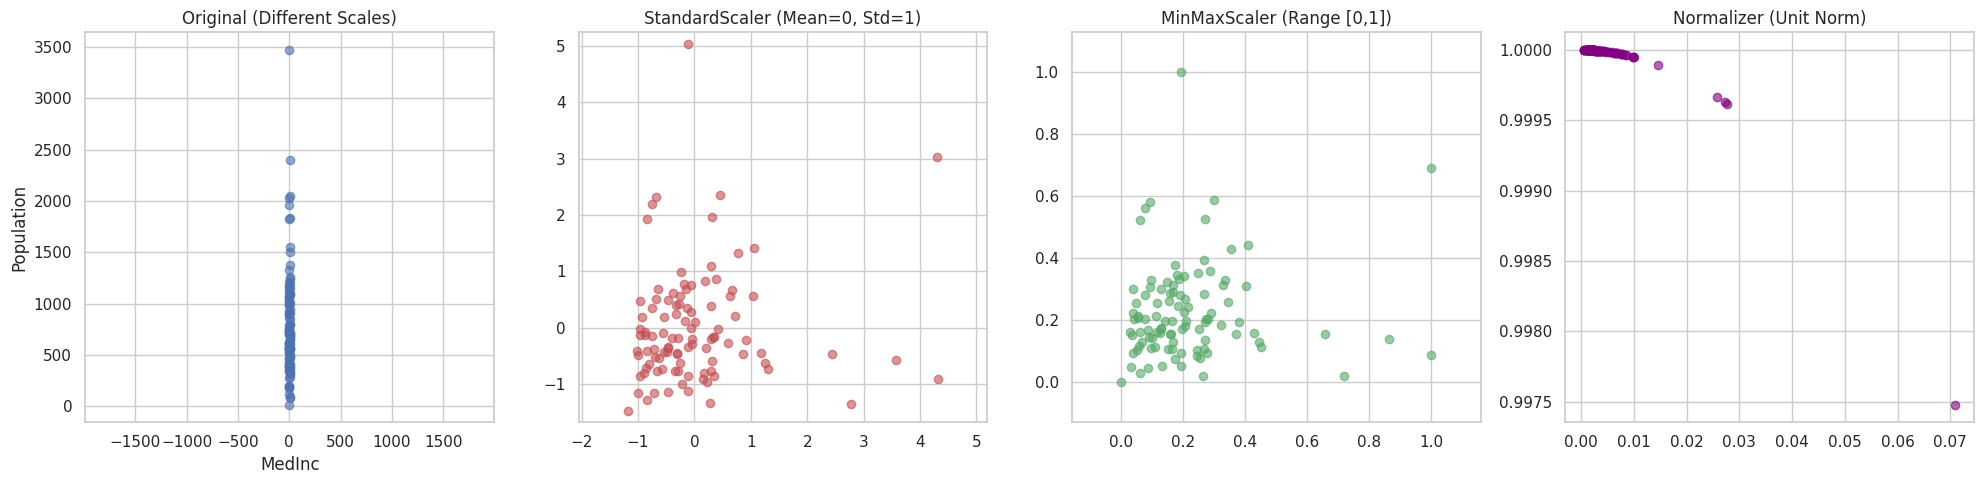

In [ ]:
# 3.4 Visualizing the Effect of Scaling
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].scatter(sample_data.iloc[:, 0], sample_data.iloc[:, 1], alpha=0.6)
axes[0].set_title("Original (Different Scales)")
axes[0].set_xlabel("MedInc")
axes[0].set_ylabel("Population")
axes[0].axis('equal')

axes[1].scatter(scaled_std[:, 0], scaled_std[:, 1], alpha=0.6, color='r')
axes[1].set_title("StandardScaler (Mean=0, Std=1)")
axes[1].axis('equal')

axes[2].scatter(scaled_mm[:, 0], scaled_mm[:, 1], alpha=0.6, color='g')
axes[2].set_title("MinMaxScaler (Range [0,1])")
axes[2].axis('equal')

axes[3].scatter(scaled_sph[:, 0], scaled_sph[:, 1], alpha=0.6, color='purple')
axes[3].set_title("Normalizer (Unit Norm)")

plt.tight_layout()
plt.show()

In [ ]:
# 3.5 Impact on Similarity (Distance)
print("--- Impact of Scaling on Euclidean Distance ---")
# p1: low_income, high population #96
# p2: low_income, higher population #95
# p3: high_income, high population #1
indices = [96, 95, 1]
subset = sample_data.iloc[indices]
display(subset)

dist_raw = cdist(subset, subset)
print("\nEuclidean distance on raw data:")
display(pd.DataFrame(dist_raw, index=indices, columns=indices))

subset_std = scaled_std[indices]
dist_std = cdist(subset_std, subset_std)
print("\nEuclidean distance on standardized data:")
display(pd.DataFrame(dist_std, index=indices, columns=indices))

print("\nNotice how the distance in the original space is dominated by the 'Population' feature.")
print("After standardization, the 'MedInc' feature contributes equally to the distance calculation.")

--- Impact of Scaling on Euclidean Distance ---


,MedInc,Population
96,2.8345,2048.0
95,2.0096,3469.0
1,8.3014,2401.0



Euclidean distance on raw data:


,96,95,1
96,0.000000,1421.000239,353.042330
95,1421.000239,0.000000,1068.018533
1,353.042330,1068.018533,0.000000



Euclidean distance on standardized data:


,96,95,1
96,0.000000,2.744970,3.899897
95,2.744970,0.000000,4.860377
1,3.899897,4.860377,0.000000



Notice how the distance in the original space is dominated by the 'Population' feature.
After standardization, the 'MedInc' feature contributes equally to the distance calculation.


## 4. Feature Selection

### 4.1 Theoretical Foundation
Feature Selection reduces noise, improves model interpretability, and combats the "Curse of Dimensionality".

#### 4.1.1 Pearson Correlation
Measures the **linear** relationship between two variables. It is defined as the covariance of the two variables divided by the product of their standard deviations:
$$\rho_{X,Y} = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y}$$
Range: [-1, 1]. 1 means perfect positive linear correlation, -1 means perfect negative linear correlation.

#### 4.1.2 Mutual Information (MI)
Measures the **statistical dependency** (both linear and non-linear) between variables. It is based on the concept of **Entropy** ($H$). MI between $X$ and $Y$ is the reduction in uncertainty about $X$ given knowledge of $Y$:
$$I(X;Y) = H(X) - H(X|Y)$$
Range: [0, $\infty$]. 0 means the variables are independent.

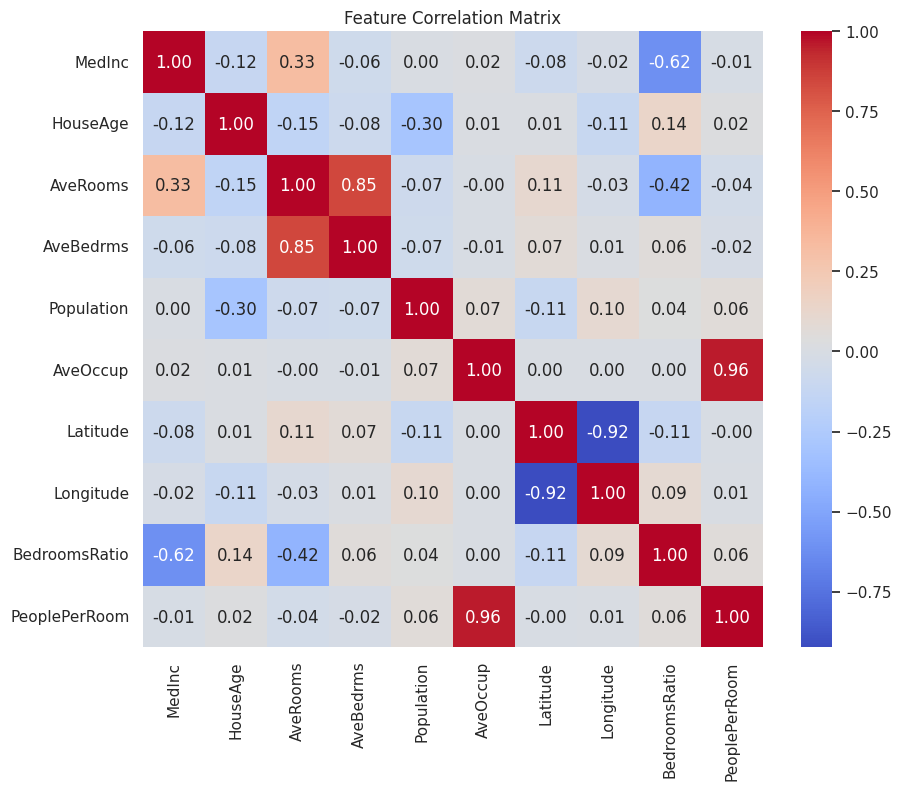

In [ ]:
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression

# 4.2 Feature Engineering (Creating Ratios)
df_fs = pd.DataFrame(housing.data, columns=housing.feature_names)
df_fs['MedHouseVal'] = housing.target
df_fs['BedroomsRatio'] = df_fs['AveBedrms'] / df_fs['AveRooms']
df_fs['PeoplePerRoom'] = df_fs['AveOccup'] / df_fs['AveRooms']

# 4.3 Comparing Correlation vs. Mutual Information
X_fs = df_fs.drop('MedHouseVal', axis=1)
y_fs = df_fs['MedHouseVal']

# Visualizing Redundant Features
plt.figure(figsize=(10, 8))
sns.heatmap(X_fs.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

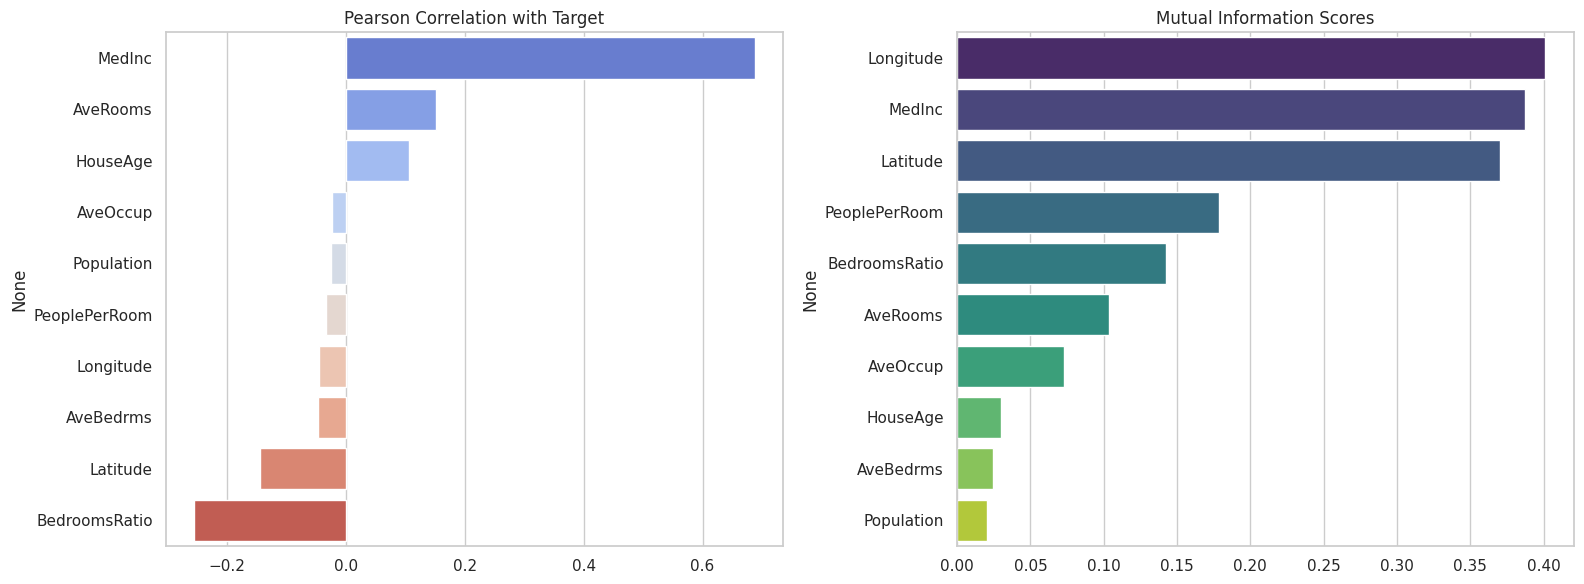

In [ ]:
# compare which features are more informative about the target variable

correlations_with_y = df_fs.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
mi_scores = mutual_info_regression(X_fs, y_fs, random_state=42)
mi_series = pd.Series(mi_scores, index=X_fs.columns).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=correlations_with_y.values, y=correlations_with_y.index, hue=correlations_with_y.index, ax=ax1, palette='coolwarm', legend=False)
ax1.set_title("Pearson Correlation with Target")
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, ax=ax2, palette='viridis', legend=False)
ax2.set_title("Mutual Information Scores")
plt.tight_layout()
plt.show()

**Conclusion**: We should drop features that are highly correlated with each other (redundant) but have low correlation/MI with the target variable.

### 4.4 Automatic Feature Selection in Scikit-Learn
Scikit-Learn provides several tools for automatic feature selection:
- **`SelectKBest`**: Selects the top $k$ features based on a scoring function (e.g., `f_regression` for linear relationships or `mutual_info_regression` for non-linear ones). Does not considere multi-collinearity, you should filter them before.
- **`Recursive Feature Elimination (RFE)`**: Greedily removes features by training a model and checking feature importance.

In [ ]:
# Example of SelectKBest
selector = SelectKBest(score_func=mutual_info_regression, k=5)
X_new = selector.fit_transform(X_fs, y_fs)
selected_features = X_fs.columns[selector.get_support()]
print(f"Top 5 features selected by f_regression: {list(selected_features)}")

Top 5 features selected by f_regression: ['MedInc', 'Latitude', 'Longitude', 'BedroomsRatio', 'PeoplePerRoom']


In [ ]:
# Drop higlhy correlated features before the selection
correlations = X_fs.corr()
np.fill_diagonal(correlations.values,0)
display(correlations.loc[(correlations.abs()>0.9).any(),(correlations.abs()>0.9).any()])

X_fs_red = X_fs.drop(['Longitude','AveOccup'], axis='columns')
X_new = selector.fit_transform(X_fs_red, y_fs)
selected_features = X_fs_red.columns[selector.get_support()]
print(f"Top 5 features selected by f_regression: {list(selected_features)}")


,AveOccup,Latitude,Longitude,PeoplePerRoom
AveOccup,0.000000,0.002366,0.002476,0.959563
Latitude,0.002366,0.000000,-0.924664,-0.004598
Longitude,0.002476,-0.924664,0.000000,0.005178
PeoplePerRoom,0.959563,-0.004598,0.005178,0.000000


Top 5 features selected by f_regression: ['MedInc', 'AveRooms', 'Latitude', 'BedroomsRatio', 'PeoplePerRoom']


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso

# Initialize the estimator (must have .coef_ or .feature_importances_)
estimator = Lasso() # here you might use more complex models (we will see some in remaining of the course)

# Select the top 3 features using RFE
selector = RFE(estimator, n_features_to_select=5)
selector = selector.fit(X_fs, y_fs)

# Identify selected features
selected_mask = selector.support_
print(f"Selected features: {X_fs.columns[selected_mask]}")

Selected features: Index(['MedInc', 'HouseAge', 'Population', 'BedroomsRatio', 'PeoplePerRoom'], dtype='object')


## 5. Text Representation

### 5.1 Statistical: TF-IDF
**TF-IDF** (Term Frequency-Inverse Document Frequency) is a numerical statistic that reflects how important a word is to a document in a collection or corpus.

#### 5.1.1 The Intuition
- **Term Frequency (TF)**: How often a word appears in a document. High TF means the word is important *within* that document.
- **Inverse Document Frequency (IDF)**: How rare a word is across the entire corpus. High IDF means the word is unique and helps distinguish documents.

Formula: $TFIDF(t, d) = TF(t, d) \times \log(\frac{N}{DF(t)})$

**Dictionary Concept**: The vectorizer builds a "dictionary" of all unique words in the corpus. Each document is then represented as a vector where each dimension corresponds to a word in the dictionary.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.manifold import TSNE

# 5.1.2 Loading Text Data
categories = ['sci.med', 'comp.graphics', 'alt.atheism']
newsgroups = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))
print(newsgroups.DESCR)

.. _20newsgroups_dataset:

The 20 newsgroups text dataset
------------------------------

The 20 newsgroups dataset comprises around 18000 newsgroups posts on
20 topics split in two subsets: one for training (or development)
and the other one for testing (or for performance evaluation). The split
between the train and test set is based upon a messages posted before
and after a specific date.

This module contains two loaders. The first one,
:func:`sklearn.datasets.fetch_20newsgroups`,
returns a list of the raw texts that can be fed to text feature
extractors such as :class:`~sklearn.feature_extraction.text.CountVectorizer`
with custom parameters so as to extract feature vectors.
The second one, :func:`sklearn.datasets.fetch_20newsgroups_vectorized`,
returns ready-to-use features, i.e., it is not necessary to use a feature
extractor.

**Data Set Characteristics:**

=================   ==========
Classes                     20
Samples total            18846
Dimensionality               1

In [ ]:
newsgroups.data[0]

'\nBut it\'s STILL HAPPENING.  That\'s the entire point.  Only last month, John\nMajor hailed it as a great victory that he had personally secured a sale of\narms to Saudi Arabia.  The same month, we sold jet fighters to the same\nIndonesian government that\'s busy killing the East Timorese.\n\nIt\'s all very well to say "Oops, we made a boo-boo, better clean up the\nmistake", but the US and UK *keep* making the *same* mistake.  They do it so\noften that I can\'t believe it\'s not deliberate.  This suspicion is reinforced\nby the fact that the mistake is an extremely profitable one for a decrepit\neconomy reliant on arms sales.\n\n\nNo, I thought both were terrible.\n'

In [ ]:
len(newsgroups.data)

1104

In [ ]:
# 5.1.3 Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(newsgroups.data)

tfidf_matrix.shape
# # Visualizing the Dictionary (Vocabulary)
vocab = vectorizer.get_feature_names_out()
print(f"Vocabulary Size: {len(vocab)}")
print(f"Sample words from dictionary: {vocab[10000:10020]}")


Vocabulary Size: 20818
Sample words from dictionary: ['individual' 'individually' 'individuals' 'indoctrination' 'indonesia'
 'indonesian' 'indonesie' 'indroduction' 'induce' 'induced' 'induces'
 'inducing' 'inductance' 'induction' 'inductive' 'indulgence' 'indulgent'
 'industrial' 'industrialized' 'industries']


In [ ]:
tfidf_matrix[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45 stored elements and shape (1, 20818)>

In [ ]:
# Showing Representation of Two Texts
sample_tfidf = tfidf_matrix[:2].toarray()

print(sample_tfidf)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
# Show top 5 words by TF-IDF score
for i, text in enumerate(newsgroups.data[:2]):
    print(f"\n--- Text {i+1} ---")
    print(text[:150] + "...")
    # Get top 5 words by TF-IDF score
    top_indices = sample_tfidf[i].argsort()[-5:][::-1]
    top_words = [(vocab[idx], f"{sample_tfidf[i][idx]:.4f}") for idx in top_indices]
    print(f"Top 5 TF-IDF words: {top_words}")



--- Text 1 ---

But it's STILL HAPPENING.  That's the entire point.  Only last month, John
Major hailed it as a great victory that he had personally secured a sale o...
Top 5 TF-IDF words: [('mistake', '0.3561'), ('boo', '0.3190'), ('arms', '0.2534'), ('month', '0.2089'), ('economy', '0.1595')]

--- Text 2 ---
Dear news readers,

Is there anyone using sheep models for cardiac research, specifically
concerned with arrhythmias, pacing or defibrillation? I woul...
Top 5 TF-IDF words: [('mears', '0.3011'), ('defibrillation', '0.3011'), ('sheep', '0.3011'), ('pacing', '0.3011'), ('arrhythmias', '0.2885')]


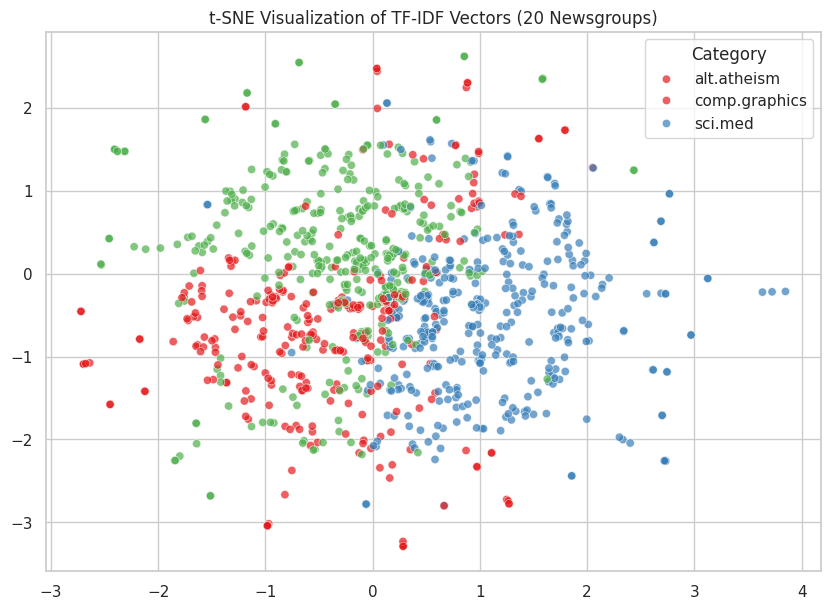

In [ ]:
# 5.1.4 t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=newsgroups.target, palette='Set1', alpha=0.7)
plt.title("t-SNE Visualization of TF-IDF Vectors (20 Newsgroups)")
plt.legend(title="Category", labels=newsgroups.target_names)
plt.show()

### 5.2 Semantic: Word2Vec (Static Embeddings)
**Word2Vec/Glove** learn dense vectors where distance represents meaning. It is based on the **Distributional Hypothesis**: "words that occur in the same contexts tend to have similar meanings".

**Key Concept**: Unlike TF-IDF, Word2Vec captures relationships. Words like "doctor" and "hospital" will be close in the vector space even if they never appear in the same document.

In [ ]:
!pip install gensim

In [ ]:
!touch /content/test

In [ ]:
import gensim.downloader as api
import os
os.environ['GENSIM_DATA_DIR'] = '/content'

# Load a pre-trained Glove model
print("Loading Glove model...")
glove_model = api.load("glove-wiki-gigaword-100")

# Show semantic similarity
pairs = [("king", "queen"), ('king','car'), ("doctor", "hospital"), ("apple", "orange"), ("car", "bicycle")]
for w1, w2 in pairs:
    print(f"Similarity between '{w1}' and '{w2}': {glove_model.similarity(w1, w2):.4f}")

Loading Glove model...
Similarity between 'king' and 'queen': 0.7508
Similarity between 'king' and 'car': 0.2830
Similarity between 'doctor' and 'hospital': 0.6901
Similarity between 'apple' and 'orange': 0.5007
Similarity between 'car' and 'bicycle': 0.6864


In [ ]:
glove_model['king']

array([-0.32307 , -0.87616 ,  0.21977 ,  0.25268 ,  0.22976 ,  0.7388  ,
       -0.37954 , -0.35307 , -0.84369 , -1.1113  , -0.30266 ,  0.33178 ,
       -0.25113 ,  0.30448 , -0.077491, -0.89815 ,  0.092496, -1.1407  ,
       -0.58324 ,  0.66869 , -0.23122 , -0.95855 ,  0.28262 , -0.078848,
        0.75315 ,  0.26584 ,  0.3422  , -0.33949 ,  0.95608 ,  0.065641,
        0.45747 ,  0.39835 ,  0.57965 ,  0.39267 , -0.21851 ,  0.58795 ,
       -0.55999 ,  0.63368 , -0.043983, -0.68731 , -0.37841 ,  0.38026 ,
        0.61641 , -0.88269 , -0.12346 , -0.37928 , -0.38318 ,  0.23868 ,
        0.6685  , -0.43321 , -0.11065 ,  0.081723,  1.1569  ,  0.78958 ,
       -0.21223 , -2.3211  , -0.67806 ,  0.44561 ,  0.65707 ,  0.1045  ,
        0.46217 ,  0.19912 ,  0.25802 ,  0.057194,  0.53443 , -0.43133 ,
       -0.34311 ,  0.59789 , -0.58417 ,  0.068995,  0.23944 , -0.85181 ,
        0.30379 , -0.34177 , -0.25746 , -0.031101, -0.16285 ,  0.45169 ,
       -0.91627 ,  0.64521 ,  0.73281 , -0.22752 , 

### 5.2.1 Visualizing Word Embeddings with t-SNE
To visualize the high-dimensional word embeddings (e.g., 100 dimensions for Glove), we need to reduce their dimensionality to 2D or 3D. t-SNE (t-Distributed Stochastic Neighbor Embedding) is a popular technique for this, as it's particularly good at preserving local structures in the data, making it suitable for visualizing clusters of similar words.

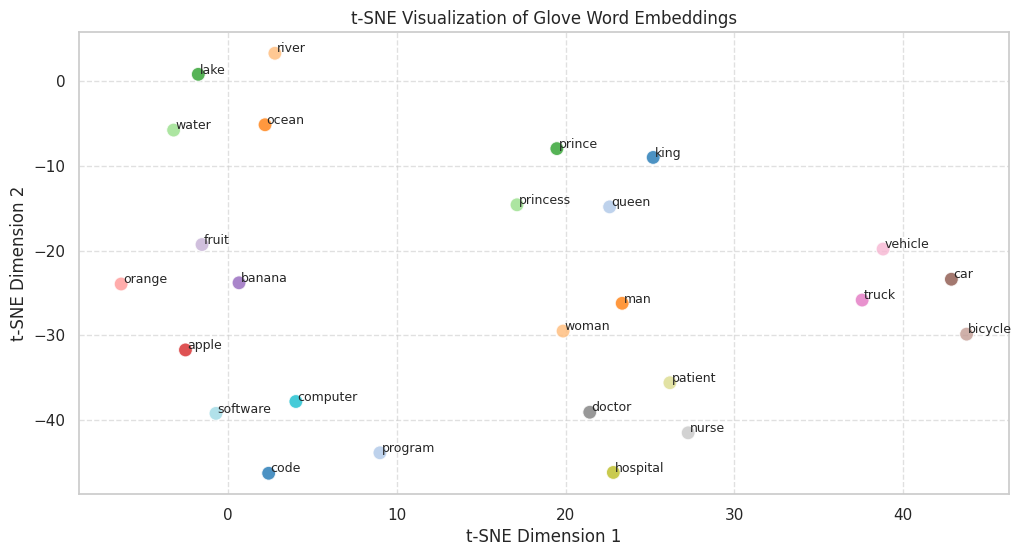

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Select a subset of words for visualization
# Choosing a mix of related and unrelated words to show clusters
words_to_visualize = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess',
    'apple', 'orange', 'banana', 'fruit',
    'car', 'bicycle', 'truck', 'vehicle',
    'doctor', 'nurse', 'hospital', 'patient',
    'computer', 'software', 'code', 'program',
    'ocean', 'river', 'lake', 'water']

# Filter out words not present in the Glove model's vocabulary
filtered_words = [word for word in words_to_visualize if word in glove_model.key_to_index]

# Get the vectors for the filtered words
word_vectors = np.array([glove_model[word] for word in filtered_words])
word_vectors

# Apply t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=3000, learning_rate='auto', init='pca')
word_vectors_2d = tsne.fit_transform(word_vectors)

# Create a DataFrame for easy plotting
df_tsne = pd.DataFrame(word_vectors_2d, columns=['x', 'y'])
df_tsne['word'] = filtered_words

# Plot the t-SNE results
plt.figure()
sns.scatterplot(
    x='x', y='y', data=df_tsne, hue='word', palette='tab20',
    s=100, alpha=0.8, legend=False
)

# Annotate points with words
for i, row in df_tsne.iterrows():
    plt.annotate(row['word'], (row['x'] + 0.1, row['y'] + 0.1), fontsize=9)

plt.title('t-SNE Visualization of Glove Word Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Vector Arithmetic: King - Man + Woman = ?
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print(f"\nVector Arithmetic: King - Man + Woman = {result[0][0]} (Score: {result[0][1]:.4f})")




Vector Arithmetic: King - Man + Woman = queen (Score: 0.7699)


**Let's play with it!**

In [ ]:
result = glove_model.most_similar(positive=['uncle', 'woman'], negative=['man'], topn=1)
print(f"\nVector Arithmetic = {result[0][0]} (Score: {result[0][1]:.4f})")

## Other ideas?
result = glove_model.most_similar(positive=['doctor', 'man'], negative=['woman'], topn=1)
print(f"\nVector Arithmetic = {result[0][0]} (Score: {result[0][1]:.4f})")




Vector Arithmetic = aunt (Score: 0.8368)

Vector Arithmetic = dr. (Score: 0.6559)


/tmp/ipykernel_258/3627806820.py:49: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='best')


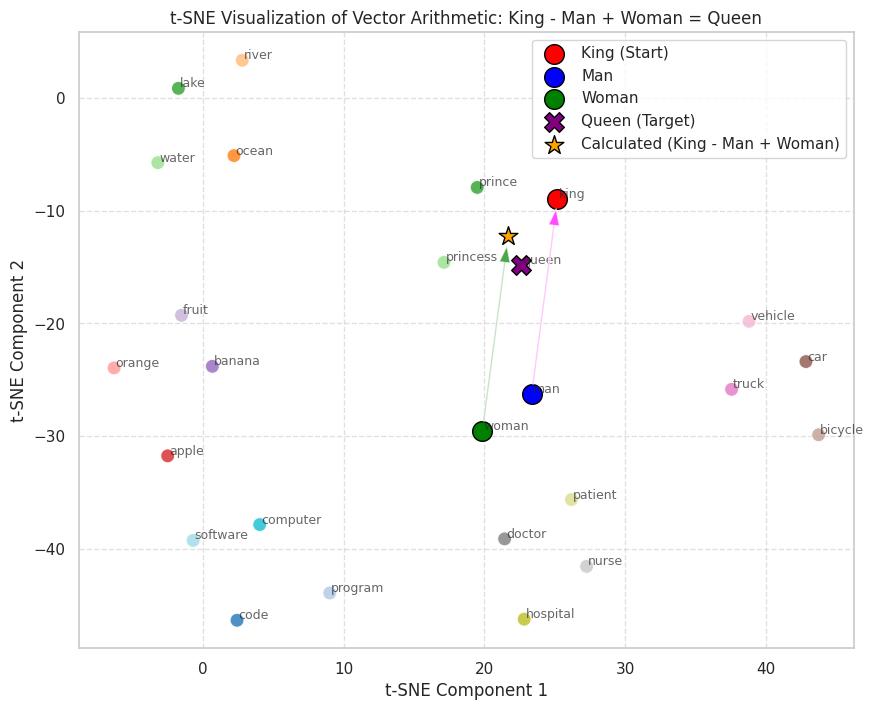

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='x', y='y', data=df_tsne, hue='word', palette='tab20',
    s=100, alpha=0.8, legend=False
)
# Annotate all words for context
for i, row in df_tsne.iterrows():
    plt.annotate(row['word'], (row['x'] + 0.1, row['y'] + 0.1), fontsize=9, alpha=0.7)


# Get coordinates for the words involved in the arithmetic
king_coords = df_tsne[df_tsne['word'] == 'king'][['x', 'y']].values[0]
man_coords = df_tsne[df_tsne['word'] == 'man'][['x', 'y']].values[0]
woman_coords = df_tsne[df_tsne['word'] == 'woman'][['x', 'y']].values[0]
queen_coords = df_tsne[df_tsne['word'] == 'queen'][['x', 'y']].values[0]

# Calculate the resultant vector in 2D PCA space
# R_vec = King_vec - Man_vec + Woman_vec
resultant_coords = king_coords - man_coords + woman_coords

# Plot the starting words with larger markers
plt.scatter(king_coords[0], king_coords[1], color='red', s=200, marker='o', edgecolors='black', label='King (Start)')
plt.scatter(man_coords[0], man_coords[1], color='blue', s=200, marker='o', edgecolors='black', label='Man')
plt.scatter(woman_coords[0], woman_coords[1], color='green', s=200, marker='o', edgecolors='black', label='Woman')

# Plot the target word 'Queen'
plt.scatter(queen_coords[0], queen_coords[1], color='purple', s=200, marker='X', edgecolors='black', label='Queen (Target)')

# Plot the calculated resultant point
plt.scatter(resultant_coords[0], resultant_coords[1], color='orange', s=200, marker='*', edgecolors='black', label='Calculated (King - Man + Woman)')


# Draw the two requested arrows
# 1. From `Man` to `King` (representing `King - Man` direction)
plt.annotate('', xy=(king_coords[0], king_coords[1]), xytext=(man_coords[0], man_coords[1]),
             arrowprops=dict(facecolor='magenta', shrink=0.05, width=1, headwidth=8, alpha=0.7),
             label='Man to King (subtraction)')

# 2. From `Woman` to the calculated resultant point (Woman + `King - Man`)
plt.annotate('', xy=(resultant_coords[0], resultant_coords[1]), xytext=(woman_coords[0], woman_coords[1]),
             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=8, alpha=0.7),
             label='Woman to Result (addition)')

plt.title('t-SNE Visualization of Vector Arithmetic: King - Man + Woman = Queen')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.show()

### 5.3 Contextual: BERT (Transformers)
**BERT** (Bidirectional Encoder Representations from Transformers) uses **Self-Attention** to generate context-aware embeddings.

**The Breakthrough**: In Word2Vec, the word "bank" has one vector. In BERT, "bank" in "river bank" and "bank account" will have different vectors because the model looks at the surrounding words to determine the meaning.

**BERT's Effectiveness**: Traditional methods often struggle with the subtle complexities and context-dependence of human language, leading to misinterpretations (e.g., sarcasm or negation). BERT, with its **contextual embeddings**, excels in sentiment analysis because:

1.  **Polysemy and Context**: Unlike static embeddings (like Word2Vec) where a word has a single representation, BERT generates different embeddings for the same word based on its surrounding context. This allows it to differentiate between "bad" in "that's a bad movie" (negative) and "that's not bad" (neutral/positive).
2.  **Bidirectional Understanding**: BERT processes text from both left-to-right and right-to-left simultaneously, capturing the full context of a word within a sentence. This comprehensive understanding is vital for grasping nuances like negations ("not good") or complex sentence structures.
3.  **Nuance and Subtlety**: By understanding the relationships between all words in a sentence, BERT can pick up on subtle cues and implicit sentiments that rule-based or bag-of-words models might miss. This makes it highly effective at discerning the true emotional tone, even in challenging cases.

In [ ]:
from transformers import BertTokenizer, BertModel
import torch
from sklearn.metrics.pairwise import cosine_similarity

# Load pre-trained BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embedding(text, word):
    inputs = tokenizer(text, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)

    word_tokens = tokenizer.tokenize(word)
    all_tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    try:
        word_idx = all_tokens.index(word_tokens[0])
        return outputs.last_hidden_state[0, word_idx, :].numpy()
    except ValueError:
        return None

s1 = "I went to the bank to deposit money."
s2 = "I sat on the river bank."
s3 = "The financial institution is closed today."

emb1 = get_bert_embedding(s1, "bank")
emb2 = get_bert_embedding(s2, "bank")
emb3 = get_bert_embedding(s3, "institution")

# print(f"Cosine Similarity between 'bank' (finance) and 'bank' (river): {cosine_similarity([emb1], [emb2])[0][0]:.4f}")
# print(f"Cosine Similarity between 'bank' (finance) and 'institution': {cosine_similarity([emb1], [emb3])[0][0]:.4f}")

print(f"Cosine Similarity between 'bank' (finance) and 'bank' (river): {cosine_similarity([emb1], [emb2])[0][0]:.4f}")
print(f"Cosine Similarity between 'bank' (finance) and 'institution': {cosine_similarity([emb1], [emb3])[0][0]:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cosine Similarity between 'bank' (finance) and 'bank' (river): 0.4750
Cosine Similarity between 'bank' (finance) and 'institution': 0.4377


### 5.3.1 Sentiment Analysis with BERT

**Sentiment Analysis** is the process of determining the emotional tone behind a piece of text. It aims to classify opinions expressed in a text as positive, negative, or neutral. This task is crucial for understanding customer feedback, social media monitoring, and market research.

**Reasoning**:
The subtask requires loading a pre-trained sentiment analysis BERT model and defining a function to predict sentiment and confidence. I will import the necessary `pipeline` function from the `transformers` library, load the pre-trained 'sentiment-analysis' pipeline, and then define a Python function `predict_sentiment` that uses this pipeline to return the sentiment label and its confidence score.



In [ ]:
from transformers import pipeline

# Load a pre-trained BERT model fine-tuned for sentiment analysis
sentiment_pipeline = pipeline('sentiment-analysis', model='finiteautomata/bertweet-base-sentiment-analysis')

# Define a function to predict sentiment and confidence
def predict_sentiment(text):
    """Predicts the sentiment label and confidence score for a given text."""
    # The pipeline returns a list of dictionaries, e.g., [{'label': 'POSITIVE', 'score': 0.999}]
    result = sentiment_pipeline(text)[0]
    sentiment_label = result['label']
    confidence_score = result['score']
    return sentiment_label, confidence_score

print("Sentiment analysis pipeline loaded and predict_sentiment function defined.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Sentiment analysis pipeline loaded and predict_sentiment function defined.


**Reasoning**:
The previous code cell successfully loaded the sentiment analysis pipeline and defined the `predict_sentiment` function. To demonstrate its usage and complete the subtask, I will now add a code cell that uses this function with example sentences and prints the sentiment and confidence score.



In [ ]:
print("\n--- Demonstrating Sentiment Prediction ---")

sentences = [
    "I love this product, it's amazing!",
    "This movie was terrible, a complete waste of time.",
    "The service was okay, nothing special.",
    "The book about ML was not too bad",
    "I am so happy today!",
    "I feel very sad about what happened."
]

for i, sentence in enumerate(sentences):
    sentiment, confidence = predict_sentiment(sentence)
    print(f"\nSentence {i+1}: '{sentence}'")
    print(f"Sentiment: {sentiment}, Confidence: {confidence:.4f}")

print("\nSentiment analysis demonstration complete.")


--- Demonstrating Sentiment Prediction ---

Sentence 1: 'I love this product, it's amazing!'
Sentiment: POS, Confidence: 0.9923

Sentence 2: 'This movie was terrible, a complete waste of time.'
Sentiment: NEG, Confidence: 0.9839

Sentence 3: 'The service was okay, nothing special.'
Sentiment: NEG, Confidence: 0.9456

Sentence 4: 'The book about ML was not too bad'
Sentiment: POS, Confidence: 0.9743

Sentence 5: 'I am so happy today!'
Sentiment: POS, Confidence: 0.9923

Sentence 6: 'I feel very sad about what happened.'
Sentiment: NEG, Confidence: 0.9572

Sentiment analysis demonstration complete.


## 6. Summary & Best Practices

| Technique | Data Type | Key Strength | Best Use Case |
| :--- | :--- | :--- | :--- |
| **One-Hot Encoding** | Categorical | No order assumption | Nominal features (Gender, Color) |
| **Standardization** | Numerical | Robust to outliers | Algorithms like SVM, PCA, Neural Nets |
| **Min-Max Scaling** | Numerical | Preserves range [0,1] | Image processing, K-NN |
| **Mutual Info** | Numerical | Captures non-linearities | Complex feature selection |
| **TF-IDF** | Text | Fast & Interpretable | Simple classification, baseline |
| **Glove** | Text | Semantic meaning | Word analogies, static embeddings |
| **BERT** | Text | Context-aware | State-of-the-art NLP, Polysemy |